<a href="https://colab.research.google.com/github/selinalee09/Python-Works/blob/main/antibiotics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
data=pd.read_csv("Bacteria_dataset_Multiresictance.csv")
print(data)


           ID                   Name                              Email  \
0        S290     Elizabeth Lawrence     elizabeth.lawrence@example.com   
1        S291           Tina Sanders           tina.sanders@example.com   
2        S292             Erin Cooke             erin.cooke@example.com   
3        S293     Mrs. Sharon Watson     mrs..sharon.watson@example.com   
4        S294          Erika Stewart          erika.stewart@example.com   
...       ...                    ...                                ...   
10705  S10995  Mrs. Chelsea Brown MD  mrs..chelsea.brown.md@example.com   
10706  S10996            Mary Kelley            mary.kelley@example.com   
10707  S10997        Alexandra Smith        alexandra.smith@example.com   
10708  S10998              April Cox              april.cox@example.com   
10709  S10999         Richard Jarvis         richard.jarvis@example.com   

                                                 Address age/gender  \
0        6350 Robinson Loaf 

In [ ]:
if "age/gender" in data.columns:
    age_gender_split = data["age/gender"].str.split("/", expand=True)
    data["Age"] = pd.to_numeric(age_gender_split[0], errors='coerce')
    data["Gender"] = age_gender_split[1].replace('?', np.nan)
    data.drop(columns=["age/gender"], inplace=True)

display(data.head())

,ID,Name,Email,Address,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,...,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,Collection_Date,Notes,Age,Gender
0,S290,Elizabeth Lawrence,elizabeth.lawrence@example.com,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",S290 Escherichia coli,No,No,No,0.0,R,...,S,S,R,S,S,S,5 Fev 2025,Patient had fever??,37.0,F
1,S291,Tina Sanders,tina.sanders@example.com,"78594 Galloway Port Suite 762, South Tanyatown...",S291 Morganella morganii,True,No,No,3.0,S,...,S,S,S,S,S,S,08/05/2021,تم العلاج,29.0,F
2,S292,Erin Cooke,erin.cooke@example.com,"76661 Isaiah Manors, North Benjamin, HI 85195",S292 Proteus mirabilis,True,No,No,3.0,S,...,S,R,R,S,S,S,01/05/2022,NADA,77.0,F
3,S293,Mrs. Sharon Watson,mrs..sharon.watson@example.com,"1670 Thompson Way Apt. 520, Andrewbury, IL 11534",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-05,PACIENTO ENFERMO,NaN,NaN
4,S294,Erika Stewart,erika.stewart@example.com,"76838 Patrick Green Suite 538, Torresmouth, ME...",S294 Escherichia coli,No,Yes,No,1.0,S,...,S,S,S,S,S,S,error,NADA,13.0,F


In [ ]:
antibiotic_cols = ["AMX/AMP", "AMC", "CZ", "FOX", "CTX/CRO", "IPM", "GEN", "AN", "Acide nalidixique", "ofx", "CIP", "C", "Co-trimoxazole", "Furanes", "colistine"]

In [ ]:
data["Species"] = data["Souches"].str.strip().str.lower()
data["Species"] = data["Souches"].astype(str).str.strip()
data["Species"] = data["Souches"].str.strip().str.replace(r"\s+", " ", regex=True)
data["Species"] = data["Souches"].str.strip().fillna("Unknown")

In [ ]:
print(f"Total Patient Samples:{len(data)}")

Total Patient Samples:10710


In [ ]:
top_bacteria=data["Species"].value_counts().head(5)
print(top_bacteria)

Species
Unknown                   640
?                          63
missing                    60
S7731 Escherichia coli      3
S6855 Escherichia coli      3
Name: count, dtype: int64


In [ ]:
resistant=data[antibiotic_cols].isin(['R'])
data['Resistant_Count']=resistant.sum()

In [ ]:
top_antibiotics = resistant.sum().sort_values(ascending=False)
print(top_antibiotics)

AMC                  5719
CTX/CRO              5660
FOX                  5644
IPM                  5635
AMX/AMP              5634
CZ                   5601
GEN                  1842
AN                   1810
CIP                  1355
Co-trimoxazole       1323
Acide nalidixique    1314
ofx                  1303
C                    1298
colistine            1264
Furanes              1225
dtype: int64


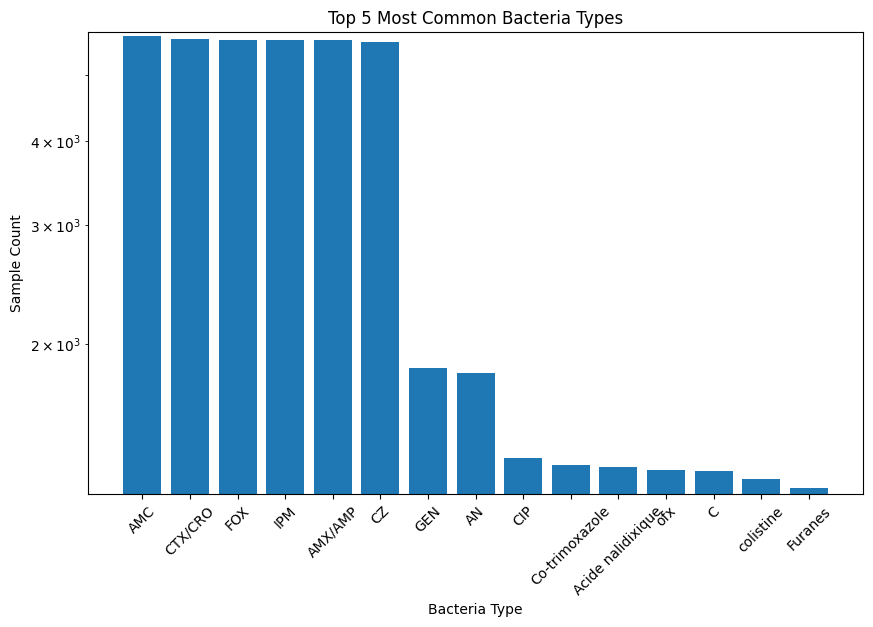

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(top_antibiotics.index, top_antibiotics.values)
plt.title("Top 5 Most Common Bacteria Types")
plt.xlabel("Bacteria Type")
plt.xticks(rotation=45)
plt.ylabel("Sample Count")
plt.ylim(bottom=1200,top=5800)
plt.yscale('log')
plt.show()

In [ ]:
gender_counts=data.groupby(["Gender", "Species"]).sum()
gender_top = gender_counts[gender_counts.index.get_level_values('Species').isin(top_bacteria.index)]
gender_top = gender_top.sort_values(by="Resistant_Count", ascending=False)
print(gender_top)

                                              ID  \
Gender Species                                     
F      S7731 Escherichia coli  S7731S10713S10985   
M      S6855 Escherichia coli  S6855S10480S10841   

                                                                     Name  \
Gender Species                                                              
F      S7731 Escherichia coli  Shannon WellsJennifer DyerAlexander Horton   
M      S6855 Escherichia coli       Nathan MorrisonCarrie RoachJohn Fritz   

                                                                           Email  \
Gender Species                                                                     
F      S7731 Escherichia coli  shannon.wells@example.comjennifer.dyer@example...   
M      S6855 Escherichia coli  nathan.morrison@example.comcarrie.roach@exampl...   

                                                                         Address  \
Gender Species                                               

<Axes: title={'center': 'Species Occurence by Gender'}, xlabel='Species', ylabel='Gender'>

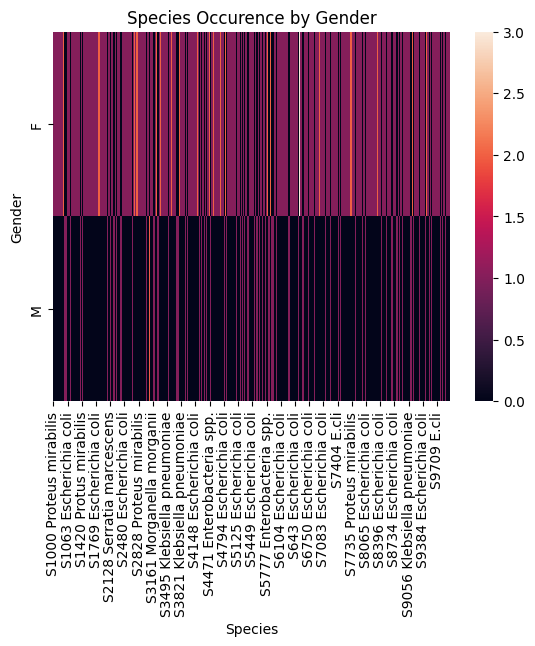

In [ ]:
import seaborn as sns
cross=pd.crosstab(data['Gender'],data['Species'])
plt.title("Species Occurence by Gender")
sns.heatmap(cross)